In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/basil/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm


In [3]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']

In [20]:
from scipy import stats, signal
def _filt(x,wts,return_weights=False):
    """
Private function to filter a time series and pad the ends of the filtered time series with NaN values. For N weights, N/2 values are padded at each end of the time series. The filter weights are normalized so that the sum of weights = 1.

Inputs:

x - the time series (may be 2d, will be filtered along columns)
wts - the filter weights
return_weights - if True, return the filter weights instead of a filtered time series (default: False)

Output:
- the filtered time series (default)
- filter weights (if `return_weights=True` is specified)
    """

    # convert to 2D array if necessary (general case)
    ndims = np.ndim(x)
    if ndims == 1:
        x = np.expand_dims(x,axis=1)

    # normalize weights
    wtsn = wts*sum(wts)**-1 # normalize weights so sum = 1

    if return_weights==False:
        # Convolve using 'direct' method. In older versions of scipy, this has to
        # be specified because the default 'auto' method could decide to use the
        # 'fft' method, which does not work for time series with NaNs. In newer
        # versions, there is no method option.
        try:
            xf = signal.convolve(x,wtsn[:,np.newaxis],mode='same',method='direct')
        except:
            xf = signal.convolve(x,wtsn[:,np.newaxis],mode='same')

        # note: np.convolve may be faster
        # http://scipy.github.io/old-wiki/pages/Cookbook/ApplyFIRFilter

        # pad ends of time series
        nwts = len(wts) # number of filter weights
        npad = int(np.ceil(0.5*nwts))
        xf[:npad,:] = np.nan
        xf[-npad:,:] = np.nan

        # return array with same number of dimensions as input
        if ndims == 1:
            xf = xf.flatten()
    elif return_weights==True:
        # return normalized weights instead of filtered time series
        xf = wtsn
    else:
        raise('return_weights must be a Boolean')

    return xf
def pl64(x=None,dt=1,T=33,return_weights=False):
    """
Filter a time series x with the PL64 filter. If x is 2D, the time series will be filtered along columns.

Inputs:
x - a numpy array to be filtered
dt - sample interval (hours), default = 1
T - half-amplitude period (hours), default = 33
return_weights - Boolean indicating whether to return the filter weights instead of a filtered time series, default = False

Output:
- numpy array of filtered time series, same size as input with ends NaN values at start and end (default)
- numpy array of filter weights (if `return_weights=True` is specified)

Reference: CODE-2: Moored Array and Large-Scale Data Report, WHOI 85-35
    """

    Tn=float(T)/dt # normalized cutoff period
    fqn=1./Tn # normalized cutoff frequency
    nw = int(np.round(64/dt)) # number of weights on one side

    # create filter weights
    j = np.arange(1,nw)
    tn = np.pi*j
    den=fqn*fqn*tn**3
    wts = (2*np.sin(2*fqn*tn)-np.sin(fqn*tn)-np.sin(3*fqn*tn))/den

    # make symmetric
    wts = np.hstack((wts[::-1],2*fqn,wts))

    xf = _filt(x,wts,return_weights)
    return xf


def filt(da,dim='time',dt=None,T=33,filter_name='pl64'):
    '''
Low pass filter a DataArray along a temporal dimension

Inputs:
da  - the DataArray to be filtered
dim - name of the temporal dimension (default 'time')
dt  - time interval of DataArray, in units of hours (default, selected automatically), for data obtained at hourly intervals, dt=1
      note: this must be consistent throughout the dataset. Specifying a value may be useful if the interval is nearly consistent, but not exactly
filter_name - name of the low pass filter (functions in physoce.tseries), should be 'pl64', 'pl66' or 'lancz' (default 'pl64')

Returns:
- the DataArray, filtered along the temporal dimension
    '''

    # automatically find time step if not specified by user
    if dt == None:
        dt_array = da[dim].diff(dim=dim)/np.timedelta64(1,'h')
        dt_unique = np.unique(dt_array)

        if len(dt_unique) == 1:
            dt = float(dt_unique)
        else:
            raise ValueError('time step must be consistent, or specified manually as input')

    # get filter weights
    if filter_name == 'pl64':
        wts = pl64(dt=dt,T=T,return_weights=True)
    elif filter_name == 'pl66':
        wts = ts.pl66(dt=dt,T=T,return_weights=True)
    elif filter_name == 'lancz':
        wts = ts.lancz(dt=dt,T=T,return_weights=True)
    else:
        raise NameError('filter_name not understood, must be pl64, pl66 or lancz')

    # filter along specified dimension
    # follows example at: http://xarray.pydata.org/en/stable/user-guide/computation.html#rolling-window-operations
    weight = xr.DataArray(wts,dims=['window'])
    daf = da.rolling({dim:len(weight)},center='True').construct({dim:'window'}).dot(weight)

    return daf

In [14]:
cutout_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/'

salt_temp_w = xr.open_dataset(cutout_path+'salt_temp_w_cape_mend.nc').isel(k=0,i=slice(0,236),j=slice(215))


In [42]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'

w_files, w_filepath = tools.get_data_paths_from_binary(path_tohd,variables[-3],file_end='nc')

w = xr.open_mfdataset(w_filepath)

In [15]:
salt_temp_w

<xarray.Dataset>
Dimensions:  (time: 9119, i: 236, j: 215)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 656 657 658 659 660 661 662 ... 886 887 888 889 890 891
  * j        (j) int64 211 212 213 214 215 216 217 ... 420 421 422 423 424 425
    XC       (i, j) float32 ...
    YC       (i, j) float32 ...
    k        int64 0
Data variables: (12/15)
    Salt     (time, i, j) float32 ...
    Theta    (time, i, j) float32 ...
    W        (time, i, j) float32 ...
    DXC      (i, j) float32 ...
    DXG      (i, j) float32 ...
    DXV      (i, j) float32 ...
    ...       ...
    Depth    (i, j) float32 ...
    RAC      (i, j) float32 ...
    RAZ      (i, j) float32 ...
    XG       (i, j) float32 ...
    YG       (i, j) float32 ...
    hFacC    (i, j) float32 ...

In [16]:
split = '2012-03-11T02:00:00'
w_first = salt_temp_w['W'].sel(time=slice('2011-11-01T00:00:00.000000000',split))
w_last = salt_temp_w['W'].sel(time=slice(split,'2012-11-14T23:00:00.000000000'))

In [18]:
w_first

<xarray.DataArray 'W' (time: 3146, i: 236, j: 215)>
[159628040 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-03-11T01:00:00
  * i        (i) int64 656 657 658 659 660 661 662 ... 886 887 888 889 890 891
  * j        (j) int64 211 212 213 214 215 216 217 ... 420 421 422 423 424 425
    XC       (i, j) float32 ...
    YC       (i, j) float32 ...
    k        int64 0

In [16]:
W=salt_temp_w['W']

In [40]:
time_diff = W['time'].diff(dim='time')/np.timedelta64(1,'h')
(W['time'].diff(dim='time')/np.timedelta64(1,'h')).round().where(time_diff==2.)#.dropna(dim='time',how='any')#/np.timedelta64(1,'h')

<xarray.DataArray 'time' (time: 9118)>
array([nan, nan, nan, ..., nan, nan, nan])
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01T01:00:00 ... 2012-11-14T23:00:00
    k        int64 0

In [21]:
W_filt = xr.concat([filt(w_first),filt(w_last)],dim='time').rename('W_filtered')

In [23]:
i_ext = [656,891]
j_ext = [211,425]
W_filt = W_filt.sel(i=slice(i_ext[0],i_ext[1]),j=slice(j_ext[0],j_ext[1]))

In [77]:
np.array(w['W'].isel(i=0,j=0,time=0))

array(-8.763912e-06, dtype=float32)

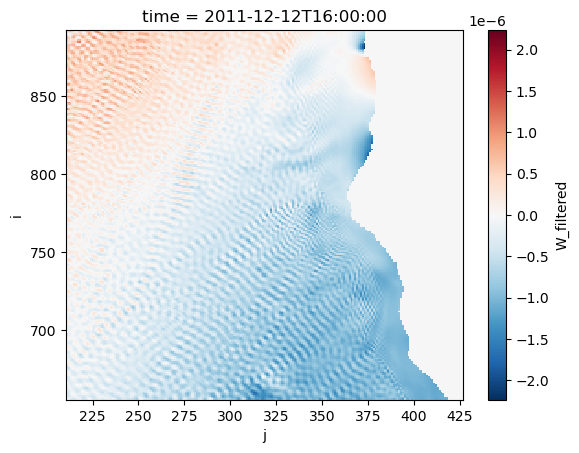

In [87]:
W_filt.isel(time=1000).plot()

In [13]:
lcs_land_nan = xr.open_dataset('/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')
lcs_land_nan.time

<xarray.DataArray 'time' (time: 1519)>
array(['2011-11-01T00:00:00.000000000', '2011-11-01T06:00:00.000000000',
       '2011-11-01T12:00:00.000000000', ..., '2012-11-14T00:00:00.000000000',
       '2012-11-14T06:00:00.000000000', '2012-11-14T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T12:00:00

In [24]:
W_filt = W_filt.sel(time=lcs_land_nan.time)
case_study_range_eddy = ['2012-07-05', '2012-08-31']

In [104]:
W_filt_eddy_cs = W_filt.sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))

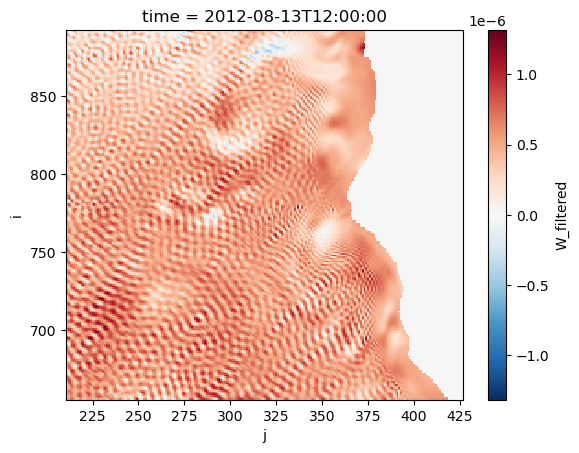

In [106]:
W_filt_eddy_cs.sel(time='2012-08-13 12:00').plot()

/tmp/ipykernel_9327/1120348461.py:1: SerializationWarning: saving variable time with floating point data as an integer dtype without any _FillValue to use for NaNs
  W_filt.to_netcdf(path_tohd+'cutouts/w_tidal_removed_lcs_cape_mend.nc')

KeyboardInterrupt



In [112]:
time = np.array(W_filt.time)
W_filt.coords['time'] = time

In [25]:
W_filt.to_netcdf(path_tohd+'cutouts/w_tidal_removed_lcs_cape_mend.nc')

### subsample W to LCS points

In [26]:
w_filt= xr.open_dataset(path_tohd+'cutouts/w_tidal_removed_lcs_cape_mend.nc')

In [22]:
w_filt_test.close()

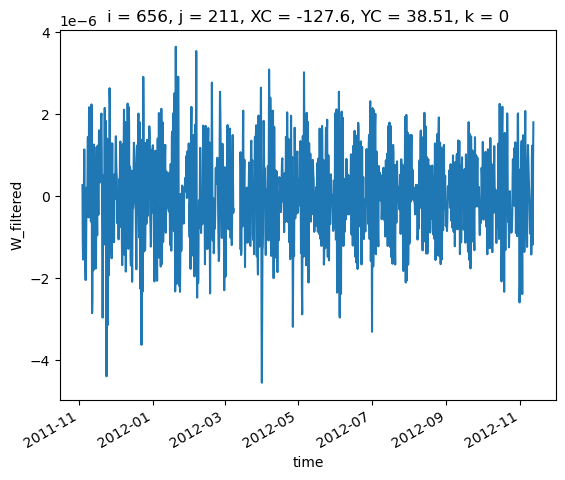

In [27]:
w_filt_test['W_filtered'].isel(j=0,i=0).plot()